In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# parametros do AG
n_pop = 30
quantidade_genes = 30
n_geracoes = 100
pop = []
nova_pop = []
n_cortes = 1
taxa_crossover = 0.8
taxa_mutacao = 0.05
selecao='torneio'

# Random seed
random_seed = 42

# Parametros da sphere
n_dimensoes = quantidade_genes
var_min = -100
var_max = 100

#elitismo
n_elitismo = 3


## Gerar População

In [3]:
# Configurar seed para reprodutibilidade
random.seed(random_seed)
np.random.seed(random_seed)

pop.clear()
#Loop para criar cada indivíduo da população:
for i in range(n_pop):
    cromossomo = [random.uniform(var_min, var_max) for _ in range(n_dimensoes)]
    pop.append(cromossomo)
    #print(f"cromossomo {i+1} gerado: {cromossomo}")
    #print("\n")


In [4]:
#pop

## Funções

In [5]:
import math

def sphere(x):
    """
    Sphere Function
    Mínimo global: f(0, ..., 0) = 0
    """
    return sum(xi**2 for xi in x)

def rastrigin(x):
    """
    Rastrigin Function
    Mínimo global: f(0, ..., 0) = 0
    """
    n = len(x)
    return 10*n + sum(xi**2 - 10*math.cos(2 * math.pi * xi) for xi in x)

def rosenbrock(x):
    """
    Rosenbrock Function
    Mínimo global: f(1, ..., 1) = 0
    """
    return sum(100 * (x[i+1] - x[i]**2)**2 + (x[i] - 1)**2 for i in range(len(x)-1))

## Avaliar cada individuo 

In [6]:
pop_aval= []
pop_aval.clear()
for cromossomo in pop:
    nota_aval = sphere(cromossomo)
    pop_aval.append((cromossomo, nota_aval))

#pop_aval
    

## Selecionar os individuos mais aptos

In [7]:
def calcular_fitness(pop_avaliada):
    """
    Recebe: lista de tuplas (cromossomo, valor_sphere)
    Retorna: lista de pesos de fitness
    """
    return [1 / (1 + individuo[1]) for individuo in pop_avaliada]

#def mostrar_probabilidade(pop_avaliada):
#    """
#    Mostra cada cromossomo com sua avaliação e probabilidade relativa
#    """
#    fitness = calcular_fitness(pop_avaliada)
#    total = sum(fitness)
#    probabilidades = [f/total for f in fitness]
#
#    for i, (crom, fitness) in enumerate(pop_avaliada):
#        print(f"Cromossomo {i+1}: avaliação={fitness:.2f}, probabilidade={probabilidades[i]*100:.2f}%")

def selecao_proporcional(pop_avaliada, n_pop_selec):
    """
    Recebe: população avaliada e quantidade a selecionar
    Retorna: apenas os cromossomos selecionados (sem o valor da sphere)
    """
    fitness = calcular_fitness(pop_avaliada)

    grupo_survivors = random.choices(pop_avaliada, weights=fitness, k=n_pop_selec)
    
    # retorna só os cromossomos, sem o valor da sphere
    return [individuo[0] for individuo in grupo_survivors]

In [8]:
#mostrar_probabilidade(pop_aval)
#len(p1_survivors)

In [9]:
def selecao_torneio(pop_avaliada, n_pop_selec):
    """
    Recebe: população avaliada [(cromossomo, avaliação), ...]
    Retorna: lista de cromossomos selecionados via torneio
    """
    grupo_survivors = []
    for rodada in range(n_pop_selec):
        # sorteiar 2 competidores
        c1, c2 = random.choices(pop_avaliada, k=2)

        # mostrar os competidores
        #print(f"Torneio {rodada+1}:")
        #print(f"  Competidor 1 -> avaliação={c1[1]:.2f}")
        #print(f"  Competidor 2 -> avaliação={c2[1]:.2f}")

        # comparar avaliações (menor é melhor)
        if c1[1] < c2[1]:
            survivor = c1
        else:
            survivor = c2

        #print(f"  Vencedor -> avaliação={survivor[1]:.2f}\n")

        grupo_survivors.append(survivor[0])  # pega só o cromossomo

    return grupo_survivors

In [10]:
def selecionar_pais(selecao, pop_avaliada, n_pop_selec):
    """
    Recebe: lista de tuplas (cromossomo, valor_sphere)          
    :param selecao: 
    :param pop_avaliada: 
    :param n_pop_selec: 
    :return: lista de p1 e p2 selecionados
    """
    if selecao.lower().strip() == 'torneio':
        p1_survivors = selecao_torneio(pop_avaliada, n_pop_selec)
        p2_survivors= selecao_torneio(pop_avaliada, n_pop_selec)
    else:
        p1_survivors = selecao_proporcional(pop_avaliada, n_pop_selec)
        p2_survivors = selecao_proporcional(pop_avaliada, n_pop_selec)
    return p1_survivors, p2_survivors


In [11]:
def crossover_1pt(p1, p2, taxa_crossover, quantidade_genes):
    """
    Recebe: dois pais (Selecionados/sobreviventes), taxa de crossover e a quantidade de genes
    Retorna: dois filhos
    """
    # verifica se há cruzamento
    if random.random() < taxa_crossover:
        ponto_corte = random.randint(1, quantidade_genes - 1)
        
        # troca as partes após o ponto de corte
        filho1 = p1[:ponto_corte] + p2[ponto_corte:]
        filho2 = p2[:ponto_corte] + p1[ponto_corte:]
        #print(f"crossover: {filho1} + {filho2}\n")
    else:
        # sem cruzamento, filhos são cópias dos pais
        filho1 = p1[:]
        filho2 = p2[:]
        #print(f"sem crossover: {filho1} + {filho2}\n")
    
    return filho1, filho2

In [12]:
def mutacao(cromossomo, taxa_mutacao, quantidade_genes, var_min, var_max):
    """
    Recebe: cromossomo, quantidade de genes, taxa de mutação e limites
    Retorna: cromossomo (com possíveis mutações)
    """
    cromossomo_mutado = cromossomo[:]  # copia para não alterar o original
    
    for i in range(quantidade_genes):
        if random.random() < taxa_mutacao:
            cromossomo_mutado[i] = random.uniform(var_min, var_max)
            #print(f"mutacao no {i+1}: {cromossomo} ---> {cromossomo_mutado}\n")
    
    return cromossomo_mutado

In [13]:
def gerar_nova_pop(p1_survivors, p2_survivors, quantidade_genes,n_pop,
                          taxa_crossover, taxa_mutacao, 
                          var_min, var_max, nova_pop):
    """
    Recebe: listas de pais selecionados, quantidade de genes, a lista de nova populção, taxas e limites
    Retorna: nova população após crossover e mutação
    """
    
    # percorre os pais em pares
    for i in range(0, n_pop):
        
        p1 = random.choice(p1_survivors)
        p2 = random.choice(p2_survivors)
        
        # crossover
        filho1, filho2 = crossover_1pt(p1, p2, taxa_crossover, quantidade_genes)
        
        # mutação em cada filho
        filho1 = mutacao(filho1, taxa_mutacao, quantidade_genes, var_min, var_max)
        filho2 = mutacao(filho2, taxa_mutacao, quantidade_genes, var_min, var_max)
        
        nova_pop.append(filho1)
        nova_pop.append(filho2)
        
    return nova_pop

## Loop exec - Critério de parada - GERAÇÕES

In [14]:
funcoes_para_testar = {'Sphere': sphere, 'Rastrigin': rastrigin, 'Rosenbrock': rosenbrock}
resultados_globais = {}

for nome_func, funcao_atual in funcoes_para_testar.items():
    print(f"\n{'='*70}")
    print(f"INICIANDO TESTES PARA A FUNÇÃO: {nome_func.upper()}")
    print(f"{'='*70}\n")

    historico_melhor_all = []
    historico_notas_all = []
    melhor_fitness_por_exec = []

    for execucao in range(30):
        # Redefinir seed para reprodutibilidade com variação
        seed_atual = 42 + execucao
        random.seed(seed_atual)
        np.random.seed(seed_atual)
        
        # Reinicializar históricos para esta execução
        historico_melhor = []
        historico_notas = []
        
        # Gerar população inicial para esta execução
        pop.clear()
        for i in range(n_pop):
            cromossomo = [random.uniform(var_min, var_max) for _ in range(n_dimensoes)]
            pop.append(cromossomo)
        
        # Loop de gerações
        for geracao in range(n_geracoes):

            # 1. Avaliar população atual (usando a funcao_atual do loop)
            pop_aval = [(crom, funcao_atual(crom)) for crom in pop]

            notas_avaliacao = [aval for _, aval in pop_aval]
            historico_notas.append(notas_avaliacao)

            # 2. Elitismo: preservar os n_elitismo melhores
            pop_aval_ord = sorted(pop_aval, key=lambda x: x[1])
            elites = [ind[0] for ind in pop_aval_ord[:n_elitismo]]

            # 3. Selecionar pais
            p1_survivors, p2_survivors = selecionar_pais(selecao, pop_aval, n_pop)

            # 4. Gerar (n_pop - n_elitismo) filhos para abrir espaço para os elites
            nova_pop.clear()
            gerar_nova_pop(p1_survivors, p2_survivors, quantidade_genes, n_pop - n_elitismo,
                           taxa_crossover, taxa_mutacao, var_min, var_max, nova_pop)

            # 5. Avaliar filhos e ordenar
            filhos_aval = [(crom, funcao_atual(crom)) for crom in nova_pop]
            filhos_aval.sort(key=lambda x: x[1])
            melhores_filhos = [ind[0] for ind in filhos_aval[:n_pop - n_elitismo]]

            # 6. Nova população = elites + melhores filhos
            pop = elites + melhores_filhos

            # 7. Registrar o melhor fitness da geração (considerando elites também)
            melhor_fitness = min(funcao_atual(ind) for ind in pop)
            historico_melhor.append(melhor_fitness)
        
        # Armazenar resultados desta execução
        historico_melhor_all.append(historico_melhor)
        historico_notas_all.append(historico_notas)
        melhor_fitness_por_exec.append(min(historico_melhor))
        
        print(f"Execução {execucao+1:02d}/30 (seed={seed_atual:3d}) | Melhor fitness final: {min(historico_melhor):.2f}")

    # Resultado final consolidado da Função atual
    resultados_globais[nome_func] = {
        'melhor_all': historico_melhor_all,
        'notas_all': historico_notas_all,
        'fitness_final': melhor_fitness_por_exec
    }

    print(f"\n{'='*60}")
    print(f"RESULTADOS FINAIS APÓS 30 EXECUÇÕES - {nome_func.upper()}")
    print(f"{'='*60}")
    print(f"Melhor fitness geral:               {min(melhor_fitness_por_exec):.2f}")
    print(f"Pior fitness (máximo observado):    {max(melhor_fitness_por_exec):.2f}")
    print(f"Fitness médio:                      {np.mean(melhor_fitness_por_exec):.2f}")
    print(f"Desvio padrão:                      {np.std(melhor_fitness_por_exec):.2f}")
    print(f"Mediana:                            {np.median(melhor_fitness_por_exec):.2f}")



INICIANDO TESTES PARA A FUNÇÃO: SPHERE

Execução 01/30 (seed= 42) | Melhor fitness final: 816.17
Execução 02/30 (seed= 43) | Melhor fitness final: 1208.44
Execução 03/30 (seed= 44) | Melhor fitness final: 936.32
Execução 04/30 (seed= 45) | Melhor fitness final: 770.57
Execução 05/30 (seed= 46) | Melhor fitness final: 747.19
Execução 06/30 (seed= 47) | Melhor fitness final: 1114.02
Execução 07/30 (seed= 48) | Melhor fitness final: 714.99
Execução 08/30 (seed= 49) | Melhor fitness final: 1647.98
Execução 09/30 (seed= 50) | Melhor fitness final: 946.00
Execução 10/30 (seed= 51) | Melhor fitness final: 1550.64
Execução 11/30 (seed= 52) | Melhor fitness final: 1121.35
Execução 12/30 (seed= 53) | Melhor fitness final: 827.56
Execução 13/30 (seed= 54) | Melhor fitness final: 847.00
Execução 14/30 (seed= 55) | Melhor fitness final: 1034.61
Execução 15/30 (seed= 56) | Melhor fitness final: 1312.46
Execução 16/30 (seed= 57) | Melhor fitness final: 887.27
Execução 17/30 (seed= 58) | Melhor fitne

## Gráficos

C:\Users\melis\AppData\Local\Temp\ipykernel_67856\3777347161.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([melhor_fitness_por_exec], labels=[f'{nome_func} - 30 Exec'], patch_artist=True, widths=0.5)


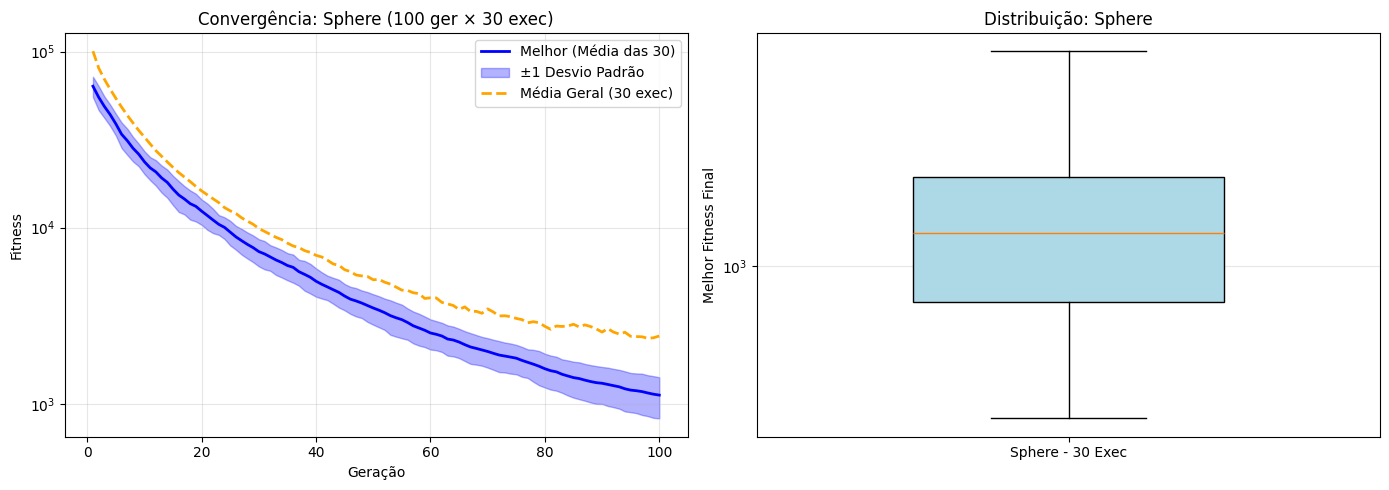

C:\Users\melis\AppData\Local\Temp\ipykernel_67856\3777347161.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([melhor_fitness_por_exec], labels=[f'{nome_func} - 30 Exec'], patch_artist=True, widths=0.5)


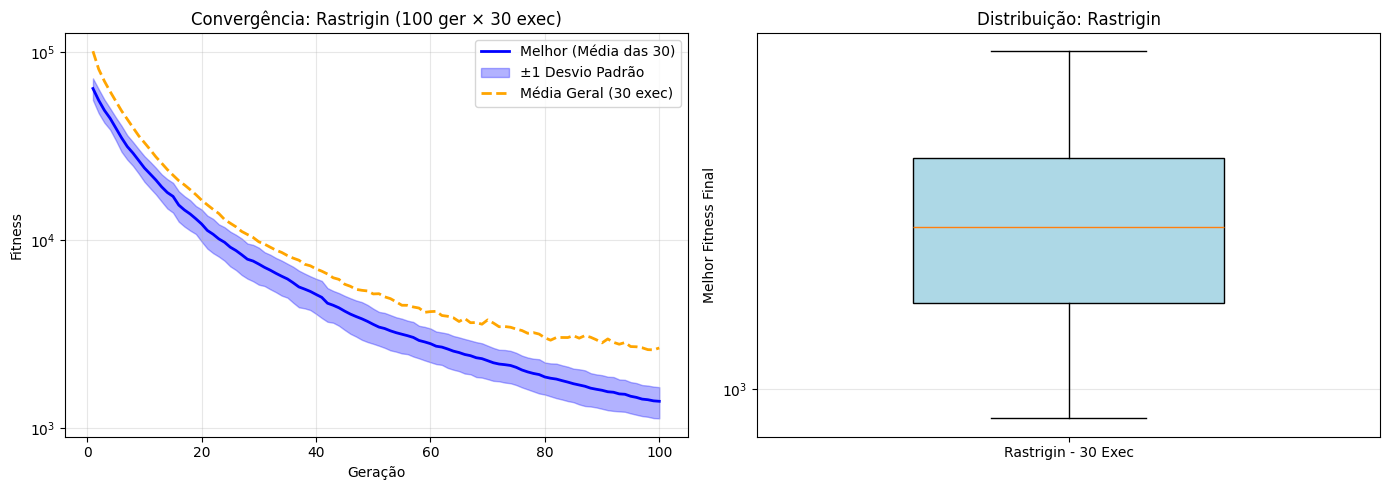

C:\Users\melis\AppData\Local\Temp\ipykernel_67856\3777347161.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([melhor_fitness_por_exec], labels=[f'{nome_func} - 30 Exec'], patch_artist=True, widths=0.5)


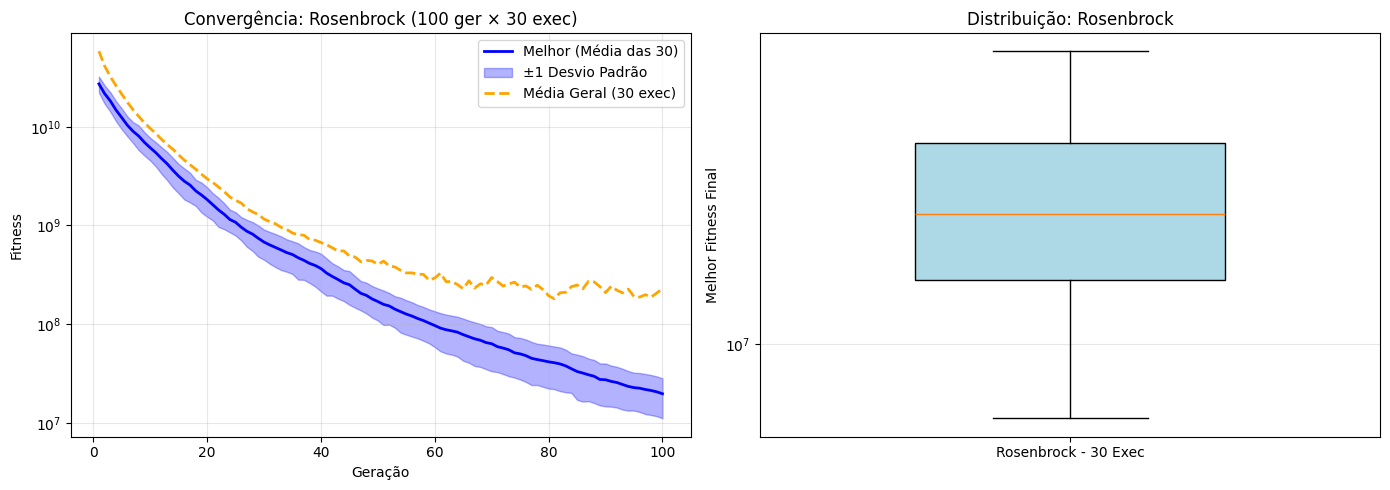

In [15]:
for nome_func, dados in resultados_globais.items():
    # Recuperando os dados da função atual
    historico_melhor_all = dados['melhor_all']
    historico_notas_all = dados['notas_all']
    melhor_fitness_por_exec = dados['fitness_final']
    
    melhor_por_geracao = []
    for geracao in range(n_geracoes):
        valores = [historico[geracao] for historico in historico_melhor_all]
        melhor_por_geracao.append(np.mean(valores))

    media_geral_por_geracao = []
    for geracao in range(n_geracoes):
        valores = []
        for historico in historico_notas_all:
            valores.extend(historico[geracao])
        media_geral_por_geracao.append(np.mean(valores))

    desvio_melhor = []
    for geracao in range(n_geracoes):
        valores = [historico[geracao] for historico in historico_melhor_all]
        desvio_melhor.append(np.std(valores))

    plt.figure(figsize=(14, 5))

    # Gráfico 1: Convergência
    plt.subplot(1, 2, 1)
    plt.plot(range(1, n_geracoes+1), melhor_por_geracao, label="Melhor (Média das 30)", linewidth=2, color='blue')
    plt.fill_between(range(1, n_geracoes+1), 
                      np.array(melhor_por_geracao) - np.array(desvio_melhor),
                      np.array(melhor_por_geracao) + np.array(desvio_melhor),
                      alpha=0.3, label="±1 Desvio Padrão", color='blue')
    plt.plot(range(1, n_geracoes+1), media_geral_por_geracao, label="Média Geral (30 exec)", linestyle="--", linewidth=2, color='orange')
    plt.xlabel("Geração")
    plt.ylabel("Fitness")
    plt.title(f"Convergência: {nome_func} ({n_geracoes} ger × 30 exec)")
    plt.yscale('symlog') 
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Gráfico 2: Boxplot
    plt.subplot(1, 2, 2)
    bp = plt.boxplot([melhor_fitness_por_exec], labels=[f'{nome_func} - 30 Exec'], patch_artist=True, widths=0.5)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    plt.ylabel("Melhor Fitness Final")
    plt.title(f"Distribuição: {nome_func}")
    plt.yscale('symlog') 
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()